В цьому домашньому завданні ми реалізуємо логістичну регресію на `numpy`.
Ці завдання допоможуть вам ґрунтовно засвоїти основні концепції логістичної регресії та реалізувати їх на практиці 🔥

#### Завдання 1: Реалізація функції сигмоїди
1. З використанням `numpy` напишіть функцію `sigmoid(z)` для обчислення значення сигмоїди згідно з формулою:
   $$
   \sigma(z) = \frac{1}{1 + e^{-z}}
   $$
2. Використовуючи цю функцію, обчисліть значення сигмоїди для наступних даних: $ z = [-2, -1, 0, 1, 2] $. Виведіть результат обчислень.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def sigmoid(z):
    sigma = 1 / (1 + np.exp(-z))
    return sigma

In [3]:
z = np.array([-2, -1, 0, 1, 2])

In [4]:
sigma = sigmoid(z)

In [5]:
sigma

array([0.11920292, 0.26894142, 0.5       , 0.73105858, 0.88079708])



#### Завдання 2: Реалізація функції гіпотези для логістичної регресії
1. Напишіть функцію `hypothesis(theta, X)`, яка обчислює гіпотезу для логістичної регресії, використовуючи функцію сигмоїди. Формула гіпотези:
   $$
   h_\theta(x) = \sigma(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}
   $$
2. Використайте функцію `hypothesis` для обчислення значень гіпотези для наступних даних:
   
   $\theta = [0.5, -0.5]$
   
   $X = \begin{bmatrix} 1 & 2 \\ 1 & -1 \\ 1 & 0 \\ 1 & 1 \end{bmatrix}$

  Виведіть результат обчислень.


In [6]:
theta = np.array([0.5, -0.5])
X = np.array([[1, 2], [1, -1], [1, 0], [1, 1]])

In [7]:
theta, X

(array([ 0.5, -0.5]),
 array([[ 1,  2],
        [ 1, -1],
        [ 1,  0],
        [ 1,  1]]))

In [8]:
theta.shape

(2,)

In [9]:
X.T.shape

(2, 4)

In [10]:
def hypothesis(theta, X):
    arg = np.dot(X, theta)
    sigma = sigmoid(arg)
    return sigma

In [11]:
h_theta = hypothesis(theta, X)
h_theta

array([0.37754067, 0.73105858, 0.62245933, 0.5       ])

In [12]:
h_theta.shape

(4,)

#### Завдання 3: Реалізація функції для підрахунку градієнтів фукнції втрат
1. Напишіть функцію `compute_gradient(theta, X, y)`, яка обчислює градієнти функції втрат для логістичної регресії. Формула для обчислення градієнта:
   $$
   \frac{\partial L(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} \left[ (h_\theta(x^{(i)}) - y^{(i)}) x_j^{(i)} \right]
   $$
2. Використайте функцію `compute_gradient` для обчислення градієнтів для наступних даних:

  $\theta = [0.5, -0.5]$

  $X = \begin{bmatrix} 1 & 2 \\ 1 & -1 \\ 1 & 0 \\ 1 & 1 \end{bmatrix}$

  $y = [1, 0, 1, 0]$

  Виведіть результат обчислень.

In [13]:
y = np.array([1, 0, 1, 0])
y

array([1, 0, 1, 0])

In [14]:
y.shape

(4,)

In [15]:
X.T.shape

(2, 4)

In [16]:
def compute_gradient(theta, X, y):
    m = len(y)
    h_theta = hypothesis(theta, X)
    diff = h_theta - y
    grad = np.dot(X.T, diff) / m
    return grad

In [17]:
compute_gradient(theta, X, y)

array([ 0.05776464, -0.36899431])


#### Завдання 4: Реалізація повного батч градієнтного спуску

**Задача:**
1. Напишіть функцію `full_batch_gradient_descent(X, y, lr=0.1, epochs=100)`, яка реалізує алгоритм Full градієнтного спуску для логістичної регресії. Використовуйте такі формули:
   - Гіпотеза: $ h_\theta(x) = \sigma(\theta^T x) $
   - Оновлення параметрів: $ \theta_j := \theta_j - \alpha \frac{\partial L(\theta)}{\partial \theta_j} $
2. Використайте функцію `full_batch_gradient_descent` для обчислення параметрів моделі на наступних даних:

  $X = \begin{bmatrix} 1 & 2 \\ 1 & -1 \\ 1 & 0 \\ 1 & 1 \end{bmatrix}$

  $y = [1, 0, 1, 0]$

  Увага! Матриця $X$ вже має стовпець одиниць і передбачається, що це. - стовпець для intercept - параметра зсуву.

  Виведіть результат обчислень.


In [18]:
# Градієнтний спуск
def full_batch_gradient_descent(X, y, lr=0.1, epochs=100):
    theta = np.array([0, 0]) # Початкові параметри
    errors = []
    for _ in range(epochs):
        y_pred = hypothesis(theta, X)
        error = y_pred - y
        errors.append(np.sum(error**2))
        theta_gradient = compute_gradient(theta, X, y)
        theta = theta - lr * theta_gradient

    return theta, errors

theta_fbgd, errors = full_batch_gradient_descent(X, y, lr=0.1, epochs=100)

theta_fbgd

array([-0.2893693 ,  0.77655125])

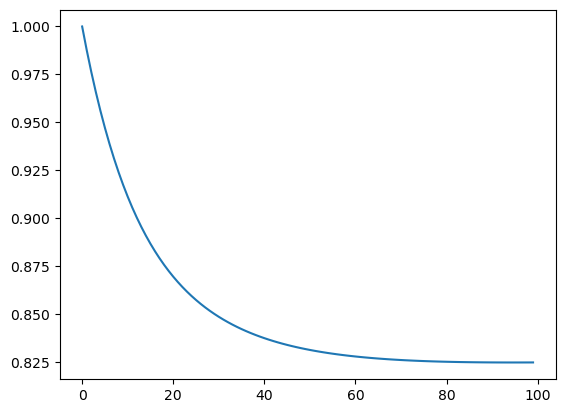

In [19]:
plt.plot(errors)

#### Завдання 5. Обчислення точності моделі

1. Напишіть функцію `predict_proba(theta, X)`, яка використовує знайдені параметри $\theta$ для обчислення ймовірностей належності поточного прикладу з даних до класу $y=1$ на основі значень $\sigma(\theta^T x)$.

2. Напишіть функцію `predict(theta, X, threshold=0.5)`, яка обчислює клас з передбаченої імовірності належності екземпляра до класу 1 з порогом 0.5. Тобто якщо ймовірність менше 0.5, то передбачаємо клас 0, інакше клас 1.

3. Напишіть функцію `accuracy(y_true, y_pred)`, яка обчислює точність моделі, визначивши частку правильно передбачених класів.

  Формула метрики Accuracy:
  $$
  \text{Accuracy} = \frac{\sum_{i=1}^{m} I(\hat{{y}^{(i)}} = y^{(i)})}{m}
  $$

  де $\hat{{y}^{(i)}}$ - передбачене значення класу, $I$ - індикаторна функція (яка дорівнює 1, якщо умова виконується, і 0 - якщо ні), $m$ - кількість прикладів.

4. Обчисліть з використанням даних в завданні 4 $X$, $y$ та обчислених коефіцієнтах $\theta$ та виведіть на екран:
  - передбачені моделлю імовірності належності кожного з екземплярів в матриці `X` до класу 1
  - класи кожного екземпляра з матриці `X`
  - точність моделі.

In [20]:
def predict_proba(theta, X):
    prob = hypothesis(theta, X)
    return prob 

In [21]:
def predict(theta, X, threshold=0.5):
    probs = predict_proba(theta, X)  
    return (probs >= threshold).astype(int)

In [22]:
def accuracy(y_true, y_pred):
    indicator = (y_true == y_pred)        
    acc = np.sum(indicator) / len(y_true)  
    return acc

In [23]:
y = np.array([1, 0, 1, 0])
X = np.array([[1, 2], [1, -1], [1, 0], [1, 1]])

y, X

(array([1, 0, 1, 0]),
 array([[ 1,  2],
        [ 1, -1],
        [ 1,  0],
        [ 1,  1]]))

In [24]:
pred = predict_proba(theta_fbgd, X)
print("передбачені моделлю імовірності належності кожного з екземплярів в матриці `X` до класу 1: ", pred)

передбачені моделлю імовірності належності кожного з екземплярів в матриці `X` до класу 1:  [0.77966809 0.25617965 0.42815828 0.61944235]


In [25]:
pred_class = predict(theta_fbgd, X, threshold=0.5)
print("класи кожного екземпляра з матриці X: ", pred_class)

класи кожного екземпляра з матриці X:  [1 0 0 1]


In [26]:
print("точність моделі: ", accuracy(y, pred_class))

точність моделі:  0.5
